## PRE PROCESSING

In [2]:
import pandas as pd
import matplotlib.pyplot as plt 
import numpy as np

In [3]:
df = pd.read_parquet("US_accidents_dataset.parquet")

print(df.head())

    ID   Source  Severity           Start_Time             End_Time  \
0  A-1  Source2         3  2016-02-08 05:46:00  2016-02-08 11:00:00   
1  A-2  Source2         2  2016-02-08 06:07:59  2016-02-08 06:37:59   
2  A-3  Source2         2  2016-02-08 06:49:27  2016-02-08 07:19:27   
3  A-4  Source2         3  2016-02-08 07:23:34  2016-02-08 07:53:34   
4  A-5  Source2         2  2016-02-08 07:39:07  2016-02-08 08:09:07   

   Start_Lat  Start_Lng End_Lat End_Lng  Distance(mi)  ... Roundabout Station  \
0  39.865147 -84.058723     NaN     NaN          0.01  ...      False   False   
1  39.928059 -82.831184     NaN     NaN          0.01  ...      False   False   
2  39.063148 -84.032608     NaN     NaN          0.01  ...      False   False   
3  39.747753 -84.205582     NaN     NaN          0.01  ...      False   False   
4  39.627781 -84.188354     NaN     NaN          0.01  ...      False   False   

    Stop Traffic_Calming Traffic_Signal Turning_Loop Sunrise_Sunset  \
0  False       

In [4]:
df.isna().sum()

ID                             0
Source                         0
Severity                       0
Start_Time                     0
End_Time                       0
Start_Lat                      0
Start_Lng                      0
End_Lat                  3402762
End_Lng                  3402762
Distance(mi)                   0
Description                    5
Street                     10869
City                         253
County                         0
State                          0
Zipcode                     1915
Country                        0
Timezone                    7808
Airport_Code               22635
Weather_Timestamp         120228
Temperature(F)            163853
Wind_Chill(F)            1999019
Humidity(%)               174144
Pressure(in)              140679
Visibility(mi)            177098
Wind_Direction            175206
Wind_Speed(mph)           571233
Precipitation(in)        2203586
Weather_Condition         173459
Amenity                        0
Bump      

In [5]:
#RImuovere turning loop inutile tutti i valori sono false
#rimuovere end lat e end long che hanno più del 50% di valori mancanti
#rimuovere aeroporti, informazione ridontante con la latitudine e longitudine e città
df.drop(columns=["Turning_Loop", "End_Lat", "End_Lng", "Airport_Code"], inplace=True)

In [6]:
df['Start_Time'] = pd.to_datetime(df['Start_Time'], format='mixed')
df['End_Time'] = pd.to_datetime(df['End_Time'], format='mixed')

In [7]:
df['duration_min'] = (df['End_Time'] - df['Start_Time']).dt.total_seconds() / 60
df['hour'] = df['Start_Time'].dt.hour
df['month'] = df['Start_Time'].dt.month

# Rimuovi durate assurde (es. negativi o > 7 giorni)
df = df[(df['duration_min'] >= 0) & (df['duration_min'] < 10080)]

def is_us_holiday(dt):
    m, d = dt.month, dt.day
    
    # Natale e capodanno
    if (m == 12 and d >= 24) or (m == 1 and d <= 2):
        return 1
    # Thanksgiving (novembre, ultima settimana)
    if m == 11 and d >= 22:
        return 1
    # 4 luglio - Independence Day
    if m == 7 and d == 4:
        return 1
    # Memorial Day (fine maggio)
    if m == 5 and d >= 25:
        return 1
    # Labor Day (inizio settembre)
    if m == 9 and d <= 7:
        return 1
    # Halloween
    if m == 10 and d == 31:
        return 1
    # Super Bowl Sunday (prima domenica di febbraio ~7-10 feb)
    if m == 2 and 7 <= d <= 10:
        return 1
    
    return 0

df['is_holiday_period'] = df['Start_Time'].apply(is_us_holiday)

In [8]:
df.drop(columns=['Start_Time', 'End_Time', 'Weather_Timestamp'], inplace=True)
df.drop(columns=['Wind_Chill(F)'], inplace=True)
df.drop(columns=['Country'], inplace=True)

In [9]:
print(list(df['Weather_Condition'].unique()))

['Light Rain', 'Overcast', 'Mostly Cloudy', 'Rain', 'Light Snow', 'Haze', 'Scattered Clouds', 'Partly Cloudy', 'Clear', 'Snow', 'Light Freezing Drizzle', 'Light Drizzle', 'Fog', 'Shallow Fog', 'Heavy Rain', 'Light Freezing Rain', 'Cloudy', 'Drizzle', nan, 'Light Rain Showers', 'Mist', 'Smoke', 'Patches of Fog', 'Light Freezing Fog', 'Light Haze', 'Light Thunderstorms and Rain', 'Thunderstorms and Rain', 'Fair', 'Volcanic Ash', 'Blowing Sand', 'Blowing Dust / Windy', 'Widespread Dust', 'Fair / Windy', 'Rain Showers', 'Mostly Cloudy / Windy', 'Light Rain / Windy', 'Hail', 'Heavy Drizzle', 'Showers in the Vicinity', 'Thunderstorm', 'Light Rain Shower', 'Light Rain with Thunder', 'Partly Cloudy / Windy', 'Thunder in the Vicinity', 'T-Storm', 'Heavy Thunderstorms and Rain', 'Thunder', 'Heavy T-Storm', 'Funnel Cloud', 'Heavy T-Storm / Windy', 'Blowing Snow', 'Light Thunderstorms and Snow', 'Heavy Snow', 'Low Drifting Snow', 'Light Ice Pellets', 'Ice Pellets', 'Squalls', 'N/A Precipitation', 

In [10]:
def group_weather(w):
    if pd.isna(w):
        return 'Unknown'
    w = str(w).lower()
    
    if any(x in w for x in ['thunder', 't-storm', 'thunderstorm']):
        return 'Storm'
    if 'tornado' in w or 'funnel' in w:
        return 'Storm'
    if any(x in w for x in ['snow', 'blizzard', 'wintry', 'sleet', 'ice pellet', 'snow grain', 'freezing']):
        return 'Snow_Ice'
    if any(x in w for x in ['hail', 'small hail']):
        return 'Snow_Ice'
    if any(x in w for x in ['heavy rain', 'rain shower', 'rain']):
        return 'Rain'
    if any(x in w for x in ['drizzle', 'shower']):
        return 'Rain'
    if any(x in w for x in ['fog', 'mist', 'haze']):
        return 'Fog_Low_Visibility'
    if any(x in w for x in ['smoke', 'dust', 'sand', 'ash', 'squall']):
        return 'Dust_Smoke'
    if any(x in w for x in ['cloud', 'overcast', 'scattered', 'mostly', 'partly']):
        return 'Cloudy'
    if any(x in w for x in ['clear', 'fair', 'sunny']):
        return 'Clear'
    return 'Other'

def is_windy_condition(w):
    if pd.isna(w):
        return np.nan
    return 1 if 'windy' in str(w).lower() else 0

def weather_intensity(w):
    if pd.isna(w):
        return np.nan
    w = str(w).lower()
    if any(x in w for x in ['heavy', 'severe', 'tornado', 'funnel', 'blizzard', 'duststorm']):
        return 3
    if any(x in w for x in ['moderate', 'thunder', 't-storm', 'squall', 'wintry mix']):
        return 2
    if any(x in w for x in ['light', 'drizzle', 'mist', 'shallow', 'partial', 'patches']):
        return 1
    return 0

df['Weather_Group'] = df['Weather_Condition'].apply(group_weather)
df['Weather_Windy'] = df['Weather_Condition'].apply(is_windy_condition)
df['Weather_Intensity'] = df['Weather_Condition'].apply(weather_intensity)

df.drop(columns=['Weather_Condition'], inplace=True)

In [11]:
print(df['Street'].value_counts().head(50))
print("---")
print(f"Valori unici: {df['Street'].nunique()}")
print("---")
# Vediamo i suffissi più comuni estraendoli
import re

def extract_suffix(name):
    if pd.isna(name):
        return 'Unknown'
    # Prende l'ultima parola
    tokens = str(name).upper().split()
    return tokens[-1] if tokens else 'Unknown'

print(df['Street'].apply(extract_suffix).value_counts().head(30))

Street
I-95 N                78412
I-95 S                74502
I-5 N                 71953
I-10 E                55079
I-10 W                53205
I-5 S                 51773
I-80 W                39647
I-80 E                36091
I-405 N               32363
I-75 N                28148
I-75 S                27521
I-90 E                26417
I-15 N                24453
I-94 W                23996
I-90 W                23273
US-101 N              20041
I-95                  20013
I-94 E                19931
I-70 E                19694
I-15 S                19229
I-40 W                19020
I-84 E                18808
I-35 N                18750
I-405 S               18318
I-40 E                17798
CA-99 N               17650
I-70 W                17397
I-84 W                17237
I-64 E                16610
I-64 W                16071
CA-60 W               15305
I-35 S                15263
CA-99 S               15260
Golden State Fwy S    14869
I-20 W                14319
I-880 N      

In [12]:
import re

def classify_street(name):
    if pd.isna(name):
        return 'Unknown'
    name_upper = str(name).upper().strip()
    
    # Rimuovi direzione finale per non confonderla col tipo
    name_clean = re.sub(r'\s+(N|S|E|W|NE|NW|SE|SW)$', '', name_upper).strip()
    
    # Interstate highways (I-95, I-10 ecc.)
    if re.match(r'^I-\d+', name_clean):
        return 'Interstate'
    
    # US Routes (US-101, US-1 ecc.)
    if re.match(r'^US-\d+', name_clean):
        return 'US_Route'
    
    # State Routes (CA-99, CA-60 ecc.)
    if re.match(r'^[A-Z]{2}-\d+', name_clean):
        return 'State_Route'
    
    # Freeway con nome (Golden State Fwy, San Diego Fwy ecc.)
    if any(x in name_clean for x in ['FWY', 'FREEWAY', 'EXPRESSWAY', 'EXPY', 'TPKE', 'TURNPIKE', 'PIKE']):
        return 'Freeway_Expressway'
    
    if any(x in name_clean for x in ['HWY', 'HIGHWAY']):
        return 'Highway'
    
    if any(x in name_clean for x in ['PKWY', 'PARKWAY']):
        return 'Parkway'
    
    if any(x in name_clean for x in ['BLVD', 'BOULEVARD']):
        return 'Boulevard'
    
    if any(x in name_clean for x in [' AVE', 'AVENUE']):
        return 'Avenue'
    
    if any(x in name_clean for x in [' RD', ' ROAD']):
        return 'Road'
    
    if any(x in name_clean for x in [' ST', ' STREET']):
        return 'Street'
    
    if any(x in name_clean for x in [' DR', ' DRIVE']):
        return 'Drive'
    
    if any(x in name_clean for x in [' LN', ' LANE']):
        return 'Lane'
    
    if any(x in name_clean for x in [' TRL', ' TRAIL']):
        return 'Trail'
    
    if any(x in name_clean for x in [' CT', ' COURT', ' CIR', ' CIRCLE', ' PL', ' PLACE', ' WAY']):
        return 'Local'
    
    return 'Other'


df['Street_Type'] = df['Street'].apply(classify_street)
df.drop(columns=['Street'], inplace=True)

In [13]:
print(df['Street_Type'].value_counts())

Street_Type
Interstate            1921099
Road                  1199431
Street                 697910
Avenue                 651236
Freeway_Expressway     610686
Highway                563576
State_Route            490869
Boulevard              343529
Drive                  319894
Other                  289323
US_Route               209633
Parkway                192585
Local                   96503
Lane                    88463
Trail                   35978
Unknown                 10853
Name: count, dtype: int64


In [14]:
def light_level(row):
    if row['Sunrise_Sunset'] == 'Day':
        return 4  # piena luce
    if row['Civil_Twilight'] == 'Day':
        return 3  # civil twilight
    if row['Nautical_Twilight'] == 'Day':
        return 2  # nautical twilight
    if row['Astronomical_Twilight'] == 'Day':
        return 1  # astronomical twilight
    return 0      # notte piena

df['Light_Level'] = df.apply(light_level, axis=1)
df.drop(columns=['Sunrise_Sunset', 'Civil_Twilight', 'Nautical_Twilight', 'Astronomical_Twilight'], inplace=True)

In [15]:
df.drop(columns=['ID', 'Source'], inplace=True)

In [16]:
# Mandami l'output di questi
print(df['Description'].sample(50, random_state=42).tolist())

# E anche i valori più comuni se ci sono descrizioni ripetute
print(df['Description'].value_counts().head(20))

['Right lane closed due to accident on CT-15 Northbound between Exit 34 CT-104 Long Ridge Rd and Exit 35 CT-137 High Ridge Rd.', 'Left lane blocked due to accident on I-270 Southbound at Exits 16 16A 16B MO-364.', 'At N 4500 Rd E - Accident.', 'Incident on CATTLEMEN RD near S PACKINGHOUSE RD Drive with caution.', 'At E Grand Ave/Washington St - Accident.', 'Right lane blocked due to accident on CT-15 Southbound between Exit 60 CT-10 Dixwell Ave and Exit 59 CT-69 Whalley Ave.', '#2 #3 lane blocked and right hand shoulder blocked due to accident on TX-12 Loop Northbound at Northwest Hwy. (Spur 348)\\t.', 'At Garfield Blvd/Exit 57B - Accident.', 'Center lane blocked due to accident on I-95 Northbound between Meadowlands Sports Complex and Exit 68 US-46.', 'Stationary traffic on Southern State Pkwy W from Bethpage State Pkwy/Linden St/Exit 31 (Southern State Pkwy) to Wantagh State Pkwy/Exit W4E (Southern State Pkwy) due to accident.', 'Slow traffic on Artesia Fwy E - CA-91 E from Clark Ave

In [ ]:
df['desc_length'] = df['Description'].str.len()

# Quante corsie bloccate (più corsie = più grave)
df['lanes_blocked'] = df['Description'].str.extract(r'(\d+)\s+lane', expand=False).fillna(0).astype(int)

# Tipo di blocco
df['mentions_closed'] = df['Description'].str.contains(r'closed|closure', case=False, na=False).astype(int)
df['mentions_blocked'] = df['Description'].str.contains(r'blocked', case=False, na=False).astype(int)
df['mentions_stationary'] = df['Description'].str.contains(r'stationary traffic', case=False, na=False).astype(int)
df['mentions_slow'] = df['Description'].str.contains(r'slow traffic', case=False, na=False).astype(int)
df['mentions_delay'] = df['Description'].str.contains(r'delay|expect delay', case=False, na=False).astype(int)

# Shoulder bloccata (spalla della strada)
df['mentions_shoulder'] = df['Description'].str.contains(r'shoulder', case=False, na=False).astype(int)

# Incidente non confermato vs confermato
df['unconfirmed'] = df['Description'].str.contains(r'unconfirmed', case=False, na=False).astype(int)

# Veicoli coinvolti
df['multiple_vehicles'] = df['Description'].str.contains(r'\d+\s*veh|multiple veh', case=False, na=False).astype(int)

# Tipo di strada dalla descrizione
df['desc_highway'] = df['Description'].str.contains(r'I-\d+|interstate|freeway|fwy|pkwy|expy', case=False, na=False).astype(int)

# Caution vs crash confermato
df['drive_caution'] = df['Description'].str.contains(r'drive with caution|use caution', case=False, na=False).astype(int)
df['crash_confirmed'] = df['Description'].str.contains(r'crash|accident', case=False, na=False).astype(int)

df.drop(columns=['Description'], inplace=True)

In [18]:
bool_cols = ['Amenity','Bump','Crossing','Give_Way','Junction',
             'No_Exit','Railway','Roundabout','Station','Stop',
             'Traffic_Calming','Traffic_Signal']
df[bool_cols] = df[bool_cols].astype(int)

In [19]:
for col in ['Timezone', 'Wind_Direction', 'Weather_Group', 'Street_Type']:
    df[col] = df[col].astype('category')

# Alta cardinalità → frequency encoding
for col in ['City', 'County', 'State', 'Zipcode']:
    freq = df[col].value_counts()
    df[col] = df[col].map(freq)

In [20]:
# 1. Nessuna colonna object rimasta
print(df.select_dtypes(include=['object','str']).columns.tolist())

# 2. Distribuzione target
print(df['Severity'].value_counts(normalize=True))

# 3. Shape finale
print(df.shape)

[]
Severity
2    0.796657
3    0.168263
4    0.026356
1    0.008724
Name: proportion, dtype: float64
(7721568, 50)


## SPLIT E MODEL

In [21]:
import lightgbm as lgb

In [22]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=['Severity'])
y = df['Severity'] - 1  # classi 0,1,2,3 invece di 1,2,3,4

X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y  # mantiene le proporzioni delle classi in train e test
)

print(f"Train: {X_train.shape}")
print(f"Test:  {X_test.shape}")

Train: (6177254, 49)
Test:  (1544314, 49)


In [23]:
# Seconda split: 80% train, 20% val (quindi 64% e 16% del totale)
X_train_final, X_val, y_train_final, y_val = train_test_split(
    X_train, y_train,
    test_size=0.2,
    random_state=42,
    stratify=y_train
)

print(f"Train: {X_train_final.shape}")   # ~64%
print(f"Val:   {X_val.shape}")     # ~16%
print(f"Test:  {X_test.shape}")    # ~20%

Train: (4941803, 49)
Val:   (1235451, 49)
Test:  (1544314, 49)


In [ ]:
# 1. Controlla che y_train_final abbia tutte le classi
print("Classi in y_train_final:", y_train_final.value_counts())

# 2. Controlla che le feature non siano tutte NaN o costanti
print("Feature con tutti NaN:", X_train_final.isnull().all().sum())
print("Feature costanti:", (X_train_final.nunique() == 1).sum())

In [ ]:
# Verifica che X e y siano allineati
print(X_train_final.index[:5])
print(y_train_final.index[:5])

# Verifica che non ci sia stato un reset dell'indice su uno solo dei due
print(X_train_final.index.is_monotonic_increasing)
print(y_train_final.index.is_monotonic_increasing)

In [24]:
# Reset indici su tutti i set
X_train_final = X_train_final.reset_index(drop=True)
y_train_final = y_train_final.reset_index(drop=True)
X_val = X_val.reset_index(drop=True)
y_val = y_val.reset_index(drop=True)
X_test = X_test.reset_index(drop=True)
y_test = y_test.reset_index(drop=True)

In [26]:
from sklearn.utils.class_weight import compute_sample_weight

sample_weights = compute_sample_weight(class_weight='balanced', y=y_train_final)

In [ ]:
model = lgb.LGBMClassifier(
    n_estimators=1000,
    learning_rate=0.05,
    num_leaves=127,
    min_child_samples=20,
    random_state=42,
    n_jobs=-1,
    verbose=-1,
    device='gpu',
    gpu_platform_id=0,
    gpu_device_id=0,
    objective='multiclass',
    num_class=4,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=0.1
)

In [ ]:
from sklearn.metrics import f1_score, make_scorer, classification_report, confusion_matrix

model.fit(
    X_train_final, y_train_final,
    sample_weight=sample_weights,
    eval_set=[(X_val, y_val)],
    callbacks=[
        lgb.early_stopping(stopping_rounds=50),
        lgb.log_evaluation(period=10)
    ],
    categorical_feature=['Timezone', 'Wind_Direction', 'Weather_Group', 'Street_Type']
)

print(f"Migliore iterazione: {model.best_iteration_}")

y_pred = model.predict(X_val)
print(classification_report(y_val, y_pred,
      target_names=['Severity 1','Severity 2','Severity 3','Severity 4']))

## TEST AND RESULTS

In [ ]:
import seaborn as sns

# Predizioni sul test set
y_pred_test = model.predict(X_test)

# Classification report
print("=" * 60)
print("CLASSIFICATION REPORT - TEST SET")
print("=" * 60)
print(classification_report(y_test, y_pred_test,
      target_names=['Severity 1','Severity 2','Severity 3','Severity 4']))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred_test)
cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Valori assoluti
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Sev 1','Sev 2','Sev 3','Sev 4'],
            yticklabels=['Sev 1','Sev 2','Sev 3','Sev 4'],
            ax=axes[0])
axes[0].set_title('Confusion Matrix - Valori Assoluti')
axes[0].set_ylabel('Reale')
axes[0].set_xlabel('Predetto')

# Percentuali (più utile con classi sbilanciate)
sns.heatmap(cm_percent, annot=True, fmt='.1f', cmap='Blues',
            xticklabels=['Sev 1','Sev 2','Sev 3','Sev 4'],
            yticklabels=['Sev 1','Sev 2','Sev 3','Sev 4'],
            ax=axes[1])
axes[1].set_title('Confusion Matrix - Percentuali per classe reale')
axes[1].set_ylabel('Reale')
axes[1].set_xlabel('Predetto')

plt.tight_layout()
plt.show()

# Feature importance
print("\n" + "=" * 60)
print("TOP 20 FEATURE IMPORTANCE")
print("=" * 60)
feat_imp = pd.DataFrame({
    'feature': X_test.columns,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

print(feat_imp.head(20).to_string(index=False))

plt.figure(figsize=(10, 8))
sns.barplot(data=feat_imp.head(20), x='importance', y='feature')
plt.title('Top 20 Feature Importance')
plt.tight_layout()
plt.show()

## MODEL 2 TRAIN

In [ ]:
base_weights = compute_sample_weight(class_weight='balanced', y=y_train_final)

# Poi riduci manualmente il peso della classe 0
# Prova valori tra 0.3 e 0.7 (1.0 = nessuna modifica)
scale_factor_0 = 0.7  # riduci il peso della classe 0 al 40%

sample_weights_custom = base_weights.copy()
mask_class0 = (y_train_final == 0).values
sample_weights_custom[mask_class0] *= scale_factor_0

# Verifica i pesi medi per classe
for cls in range(4):
    mask = (y_train_final == cls).values
    print(f"Classe {cls}: peso medio = {sample_weights_custom[mask].mean():.3f}")

In [ ]:
# 1. Aumenta le iterazioni, il modello non ha ancora convergito
model2 = lgb.LGBMClassifier(
    n_estimators=500 ,    
    learning_rate=0.05,
    num_leaves=127,
    min_child_samples=20,
    max_depth=10,
    random_state=42,
    n_jobs=6,
    verbose=-1,
    device='gpu',
    gpu_platform_id=0,
    gpu_device_id=0,
    objective='multiclass',
    num_class=4,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=0.1
)

In [ ]:
model2.fit(
    X_train_final, y_train_final,
    sample_weight=sample_weights_custom,  # ← questi invece di sample_weights
    eval_set=[(X_val, y_val)],
    callbacks=[
        lgb.early_stopping(stopping_rounds=100),
        lgb.log_evaluation(period=10)
    ],
    categorical_feature=['Timezone', 'Wind_Direction', 'Weather_Group', 'Street_Type']
)

In [ ]:
import seaborn as sns

# Predizioni sul test set
y_pred_test = model2.predict(X_test)

# Classification report
print("=" * 60)
print("CLASSIFICATION REPORT - TEST SET")
print("=" * 60)
print(classification_report(y_test, y_pred_test,
      target_names=['Severity 1','Severity 2','Severity 3','Severity 4']))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred_test)
cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Valori assoluti
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Sev 1','Sev 2','Sev 3','Sev 4'],
            yticklabels=['Sev 1','Sev 2','Sev 3','Sev 4'],
            ax=axes[0])
axes[0].set_title('Confusion Matrix - Valori Assoluti')
axes[0].set_ylabel('Reale')
axes[0].set_xlabel('Predetto')

# Percentuali (più utile con classi sbilanciate)
sns.heatmap(cm_percent, annot=True, fmt='.1f', cmap='Blues',
            xticklabels=['Sev 1','Sev 2','Sev 3','Sev 4'],
            yticklabels=['Sev 1','Sev 2','Sev 3','Sev 4'],
            ax=axes[1])
axes[1].set_title('Confusion Matrix - Percentuali per classe reale')
axes[1].set_ylabel('Reale')
axes[1].set_xlabel('Predetto')

plt.tight_layout()
plt.show()

# Feature importance
print("\n" + "=" * 60)
print("TOP 20 FEATURE IMPORTANCE")
print("=" * 60)
feat_imp = pd.DataFrame({
    'feature': X_test.columns,
    'importance': model2.feature_importances_
}).sort_values('importance', ascending=False)

print(feat_imp.head(20).to_string(index=False))

plt.figure(figsize=(10, 8))
sns.barplot(data=feat_imp.head(20), x='importance', y='feature')
plt.title('Top 20 Feature Importance')
plt.tight_layout()
plt.show()

In [27]:
base_weights = compute_sample_weight(class_weight='balanced', y=y_train_final)

# Poi riduci manualmente il peso della classe 0
# Prova valori tra 0.3 e 0.7 (1.0 = nessuna modifica)
scale_factor_0 = 0.2 # riduci il peso della classe 0 al 40%

sample_weights_custom = base_weights.copy()
mask_class0 = (y_train_final == 0).values
sample_weights_custom[mask_class0] *= scale_factor_0

# Verifica i pesi medi per classe
for cls in range(4):
    mask = (y_train_final == cls).values
    print(f"Classe {cls}: peso medio = {sample_weights_custom[mask].mean():.3f}")

Classe 0: peso medio = 5.731
Classe 1: peso medio = 0.314
Classe 2: peso medio = 1.486
Classe 3: peso medio = 9.486


In [28]:
# 1. Aumenta le iterazioni, il modello non ha ancora convergito
model3= lgb.LGBMClassifier(
    n_estimators=500,      
    learning_rate=0.05,
    num_leaves=127,
    min_child_samples=20,
    max_depth=10,
    random_state=42,
    n_jobs=6,
    verbose=-1,
    device='gpu',
    gpu_platform_id=0,
    gpu_device_id=0,
    objective='multiclass',
    num_class=4,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=0.1
)

In [29]:
model3.fit(
    X_train_final, y_train_final,
    sample_weight=sample_weights_custom,  # ← questi invece di sample_weights
    eval_set=[(X_val, y_val)],
    callbacks=[
        lgb.early_stopping(stopping_rounds=100),
        lgb.log_evaluation(period=10)
    ],
    categorical_feature=['Timezone', 'Wind_Direction', 'Weather_Group', 'Street_Type']
)

Training until validation scores don't improve for 100 rounds
[10]	valid_0's multi_logloss: 0.698778
[20]	valid_0's multi_logloss: 0.513682
[30]	valid_0's multi_logloss: 0.433789
[40]	valid_0's multi_logloss: 0.394452
[50]	valid_0's multi_logloss: 0.372359
[60]	valid_0's multi_logloss: 0.358825
[70]	valid_0's multi_logloss: 0.349725
[80]	valid_0's multi_logloss: 0.342984
[90]	valid_0's multi_logloss: 0.337309
[100]	valid_0's multi_logloss: 0.333042
[110]	valid_0's multi_logloss: 0.329659
[120]	valid_0's multi_logloss: 0.326989
[130]	valid_0's multi_logloss: 0.324243
[140]	valid_0's multi_logloss: 0.321847
[150]	valid_0's multi_logloss: 0.319607
[160]	valid_0's multi_logloss: 0.317597
[170]	valid_0's multi_logloss: 0.315557
[180]	valid_0's multi_logloss: 0.313937
[190]	valid_0's multi_logloss: 0.312195
[200]	valid_0's multi_logloss: 0.310588
[210]	valid_0's multi_logloss: 0.309181
[220]	valid_0's multi_logloss: 0.307714
[230]	valid_0's multi_logloss: 0.306253
[240]	valid_0's multi_loglo

,boosting_type,'gbdt'
,num_leaves,127
,max_depth,10
,learning_rate,0.05
,n_estimators,500
,subsample_for_bin,200000
,objective,'multiclass'
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


CLASSIFICATION REPORT - TEST SET
              precision    recall  f1-score   support

  Severity 1       0.28      0.85      0.42     13473
  Severity 2       0.99      0.87      0.92   1230289
  Severity 3       0.71      0.93      0.81    259850
  Severity 4       0.47      0.95      0.63     40702

    accuracy                           0.88   1544314
   macro avg       0.61      0.90      0.70   1544314
weighted avg       0.92      0.88      0.89   1544314



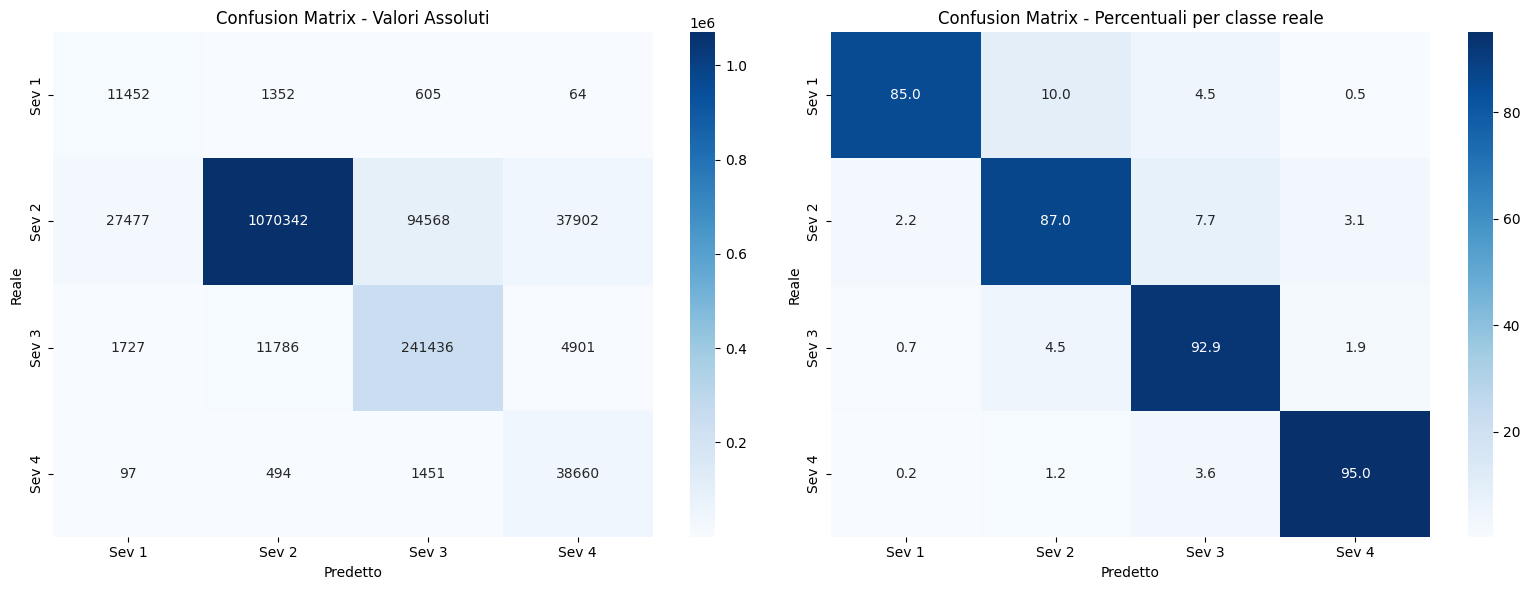


TOP 20 FEATURE IMPORTANCE
          feature  importance
     duration_min       24229
      desc_length       20046
   Wind_Direction       18999
        Start_Lat       17816
        Start_Lng       17277
     Pressure(in)       13343
     Distance(mi)       12725
      Street_Type       12459
          Zipcode       11000
            State        9981
   Temperature(F)        9832
           County        9705
             City        9377
             hour        9178
      Humidity(%)        8452
            month        7497
  Wind_Speed(mph)        5587
Precipitation(in)        4227
     desc_highway        3832
 mentions_blocked        3057


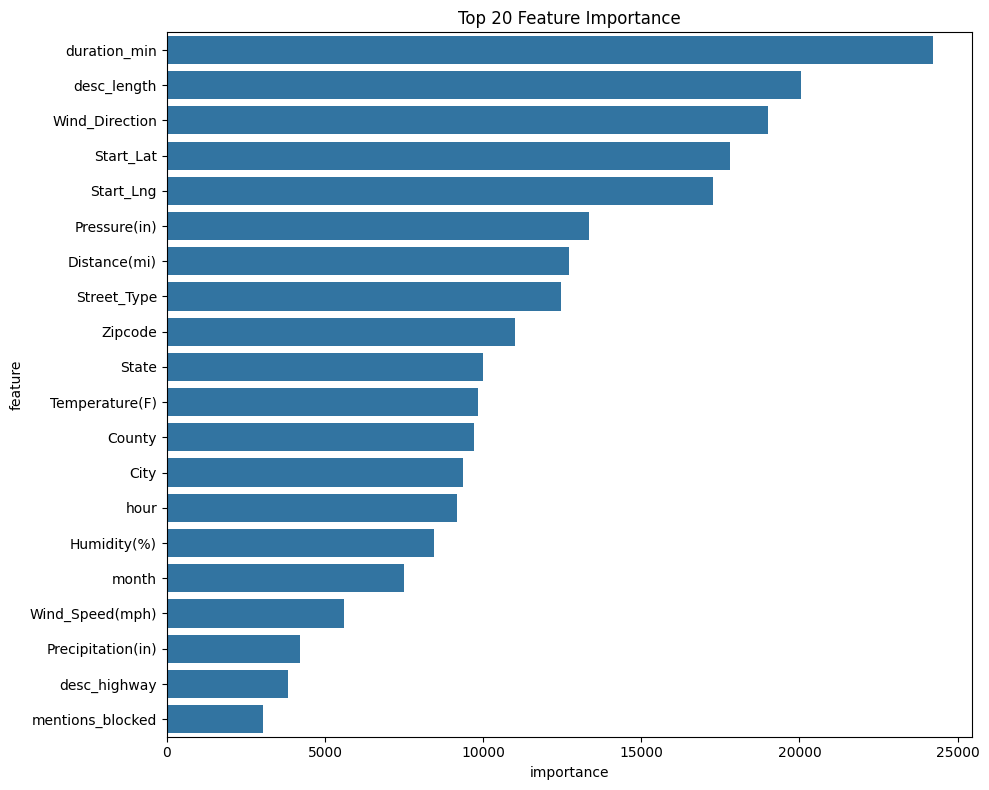

In [31]:
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

# Predizioni sul test set
y_pred_test = model3.predict(X_test)

# Classification report
print("=" * 60)
print("CLASSIFICATION REPORT - TEST SET")
print("=" * 60)
print(classification_report(y_test, y_pred_test,
      target_names=['Severity 1','Severity 2','Severity 3','Severity 4']))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred_test)
cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Valori assoluti
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Sev 1','Sev 2','Sev 3','Sev 4'],
            yticklabels=['Sev 1','Sev 2','Sev 3','Sev 4'],
            ax=axes[0])
axes[0].set_title('Confusion Matrix - Valori Assoluti')
axes[0].set_ylabel('Reale')
axes[0].set_xlabel('Predetto')

# Percentuali (più utile con classi sbilanciate)
sns.heatmap(cm_percent, annot=True, fmt='.1f', cmap='Blues',
            xticklabels=['Sev 1','Sev 2','Sev 3','Sev 4'],
            yticklabels=['Sev 1','Sev 2','Sev 3','Sev 4'],
            ax=axes[1])
axes[1].set_title('Confusion Matrix - Percentuali per classe reale')
axes[1].set_ylabel('Reale')
axes[1].set_xlabel('Predetto')

plt.tight_layout()
plt.show()

# Feature importance
print("\n" + "=" * 60)
print("TOP 20 FEATURE IMPORTANCE")
print("=" * 60)
feat_imp = pd.DataFrame({
    'feature': X_test.columns,
    'importance': model3.feature_importances_
}).sort_values('importance', ascending=False)

print(feat_imp.head(20).to_string(index=False))

plt.figure(figsize=(10, 8))
sns.barplot(data=feat_imp.head(20), x='importance', y='feature')
plt.title('Top 20 Feature Importance')
plt.tight_layout()
plt.show()

In [37]:
base_weights = compute_sample_weight(class_weight='balanced', y=y_train_final)

# Poi riduci manualmente il peso della classe 0
# Prova valori tra 0.3 e 0.7 (1.0 = nessuna modifica)
scale_factor_0 = 0.1# riduci il peso della classe 0 al 40%

sample_weights_custom = base_weights.copy()
mask_class0 = (y_train_final == 0).values
sample_weights_custom[mask_class0] *= scale_factor_0

# Verifica i pesi medi per classe
for cls in range(4):
    mask = (y_train_final == cls).values
    print(f"Classe {cls}: peso medio = {sample_weights_custom[mask].mean():.3f}")

Classe 0: peso medio = 2.866
Classe 1: peso medio = 0.314
Classe 2: peso medio = 1.486
Classe 3: peso medio = 9.486


In [41]:
# 1. Aumenta le iterazioni, il modello non ha ancora convergito
model4= lgb.LGBMClassifier(
    n_estimators=500,    
    learning_rate=0.05,
    num_leaves=127,
    min_child_samples=50,
    max_depth=10,
    random_state=42,
    n_jobs=6,
    verbose=-1,
    device='gpu',
    gpu_platform_id=0,
    gpu_device_id=0,
    objective='multiclass',
    num_class=4,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=0.1
)

In [42]:
model4.fit(
    X_train_final, y_train_final,
    sample_weight=sample_weights_custom,  # ← questi invece di sample_weights
    eval_set=[(X_val, y_val)],
    callbacks=[
        lgb.early_stopping(stopping_rounds=100),
        lgb.log_evaluation(period=10)
    ],
    categorical_feature=['Timezone', 'Wind_Direction', 'Weather_Group', 'Street_Type']
)

Training until validation scores don't improve for 100 rounds
[10]	valid_0's multi_logloss: 0.673072
[20]	valid_0's multi_logloss: 0.489651
[30]	valid_0's multi_logloss: 0.411111
[40]	valid_0's multi_logloss: 0.373103
[50]	valid_0's multi_logloss: 0.35203
[60]	valid_0's multi_logloss: 0.339121
[70]	valid_0's multi_logloss: 0.330619
[80]	valid_0's multi_logloss: 0.324583
[90]	valid_0's multi_logloss: 0.319731
[100]	valid_0's multi_logloss: 0.316099
[110]	valid_0's multi_logloss: 0.313104
[120]	valid_0's multi_logloss: 0.310445
[130]	valid_0's multi_logloss: 0.308175
[140]	valid_0's multi_logloss: 0.306213
[150]	valid_0's multi_logloss: 0.304263
[160]	valid_0's multi_logloss: 0.302288
[170]	valid_0's multi_logloss: 0.300585
[180]	valid_0's multi_logloss: 0.298934
[190]	valid_0's multi_logloss: 0.297049
[200]	valid_0's multi_logloss: 0.295478
[210]	valid_0's multi_logloss: 0.294025
[220]	valid_0's multi_logloss: 0.292746
[230]	valid_0's multi_logloss: 0.291498
[240]	valid_0's multi_loglos

,boosting_type,'gbdt'
,num_leaves,127
,max_depth,10
,learning_rate,0.05
,n_estimators,500
,subsample_for_bin,200000
,objective,'multiclass'
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,50


CLASSIFICATION REPORT - TEST SET
              precision    recall  f1-score   support

  Severity 1       0.38      0.76      0.51     13473
  Severity 2       0.99      0.88      0.93   1230289
  Severity 3       0.71      0.93      0.81    259850
  Severity 4       0.47      0.95      0.63     40702

    accuracy                           0.89   1544314
   macro avg       0.64      0.88      0.72   1544314
weighted avg       0.92      0.89      0.90   1544314



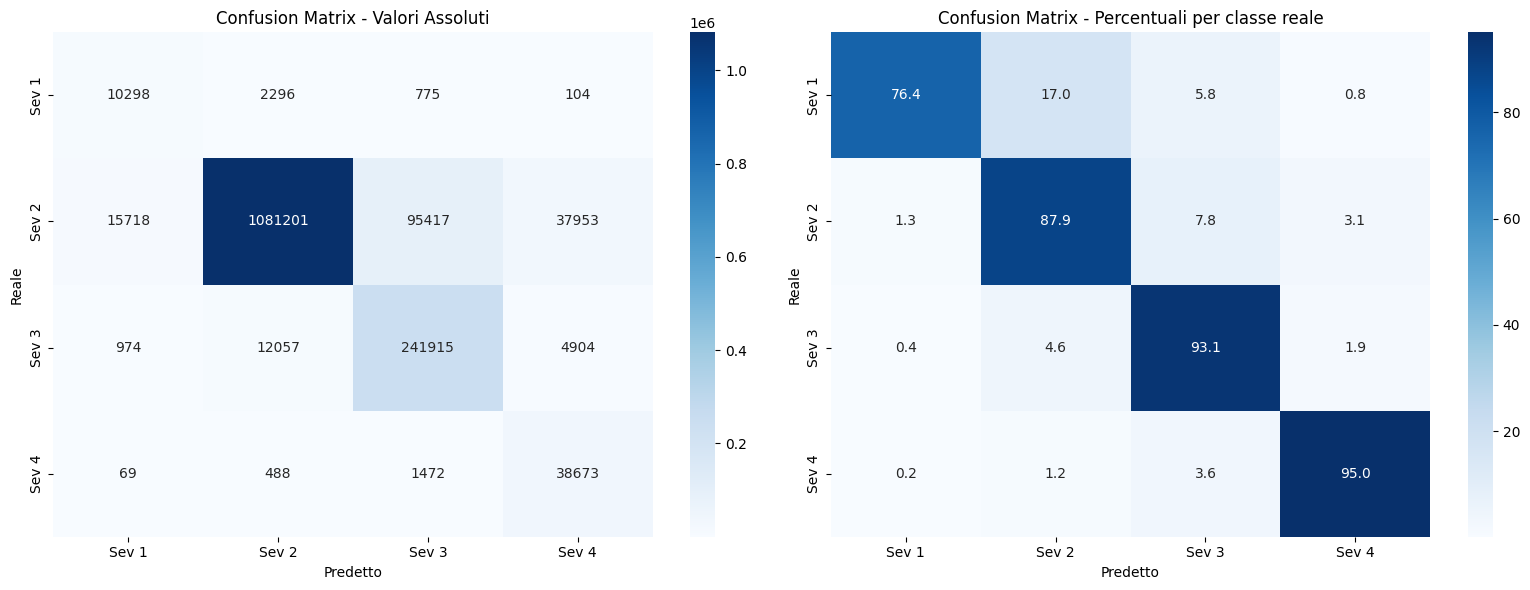


TOP 20 FEATURE IMPORTANCE
          feature  importance
     duration_min       24903
      desc_length       20145
   Wind_Direction       18326
        Start_Lat       17847
        Start_Lng       17155
     Pressure(in)       13195
     Distance(mi)       13039
      Street_Type       12137
          Zipcode       10891
            State        9954
           County        9723
   Temperature(F)        9709
             City        9364
             hour        9251
      Humidity(%)        8539
            month        7352
  Wind_Speed(mph)        5596
Precipitation(in)        4262
     desc_highway        3917
 mentions_blocked        3146


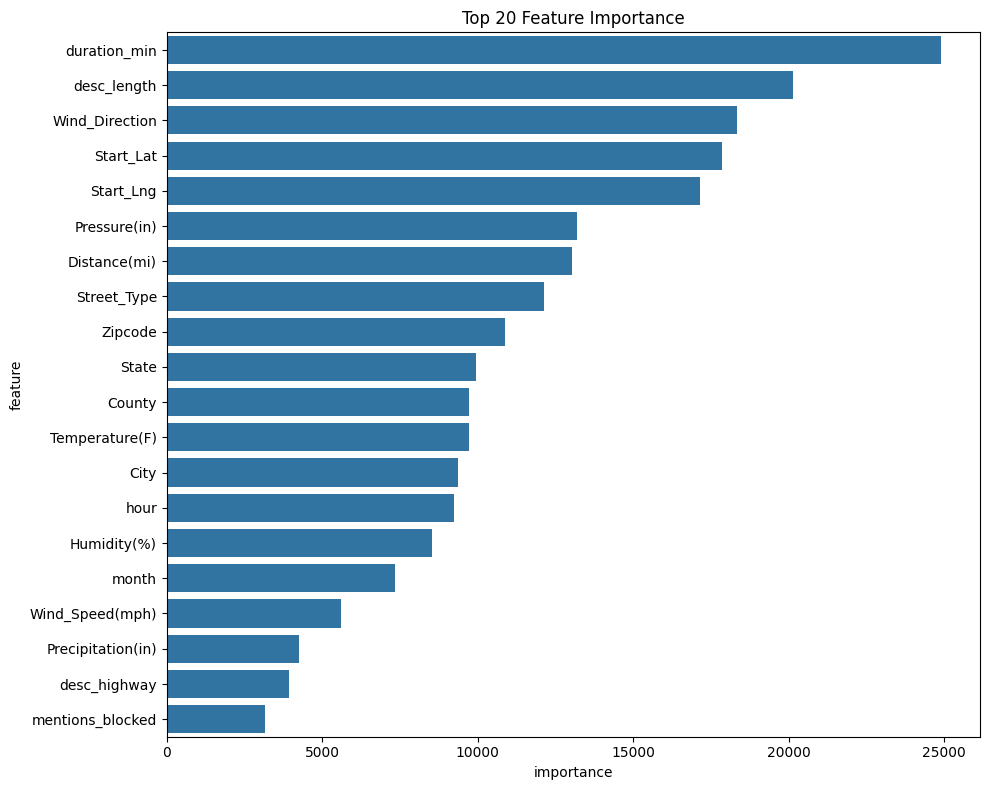

In [ ]:
import seaborn as sns

# Predizioni sul test set
y_pred_test = model4.predict(X_test)

# Classification report
print("=" * 60)
print("CLASSIFICATION REPORT - TEST SET")
print("=" * 60)
print(classification_report(y_test, y_pred_test,
      target_names=['Severity 1','Severity 2','Severity 3','Severity 4']))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred_test)
cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Valori assoluti
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Sev 1','Sev 2','Sev 3','Sev 4'],
            yticklabels=['Sev 1','Sev 2','Sev 3','Sev 4'],
            ax=axes[0])
axes[0].set_title('Confusion Matrix - Valori Assoluti')
axes[0].set_ylabel('Reale')
axes[0].set_xlabel('Predetto')

# Percentuali (più utile con classi sbilanciate)
sns.heatmap(cm_percent, annot=True, fmt='.1f', cmap='Blues',
            xticklabels=['Sev 1','Sev 2','Sev 3','Sev 4'],
            yticklabels=['Sev 1','Sev 2','Sev 3','Sev 4'],
            ax=axes[1])
axes[1].set_title('Confusion Matrix - Percentuali per classe reale')
axes[1].set_ylabel('Reale')
axes[1].set_xlabel('Predetto')

plt.tight_layout()
plt.show()

# Feature importance
print("\n" + "=" * 60)
print("TOP 50 FEATURE IMPORTANCE")
print("=" * 60)
feat_imp = pd.DataFrame({
    'feature': X_test.columns,
    'importance': model4.feature_importances_
}).sort_values('importance', ascending=False)

print(feat_imp.head(50).to_string(index=False))

plt.figure(figsize=(10, 8))
sns.barplot(data=feat_imp.head(20), x='importance', y='feature')
plt.title('Top 20 Feature Importance')
plt.tight_layout()
plt.show()


TOP 50 FEATURE IMPORTANCE
            feature  importance
       duration_min       24903
        desc_length       20145
     Wind_Direction       18326
          Start_Lat       17847
          Start_Lng       17155
       Pressure(in)       13195
       Distance(mi)       13039
        Street_Type       12137
            Zipcode       10891
              State        9954
             County        9723
     Temperature(F)        9709
               City        9364
               hour        9251
        Humidity(%)        8539
              month        7352
    Wind_Speed(mph)        5596
  Precipitation(in)        4262
       desc_highway        3917
   mentions_blocked        3146
    mentions_closed        2980
     Visibility(mi)        2292
    crash_confirmed        2141
  mentions_shoulder        1934
           Timezone        1848
        Light_Level        1800
      lanes_blocked        1344
      Weather_Group        1087
     Traffic_Signal         952
     mentions

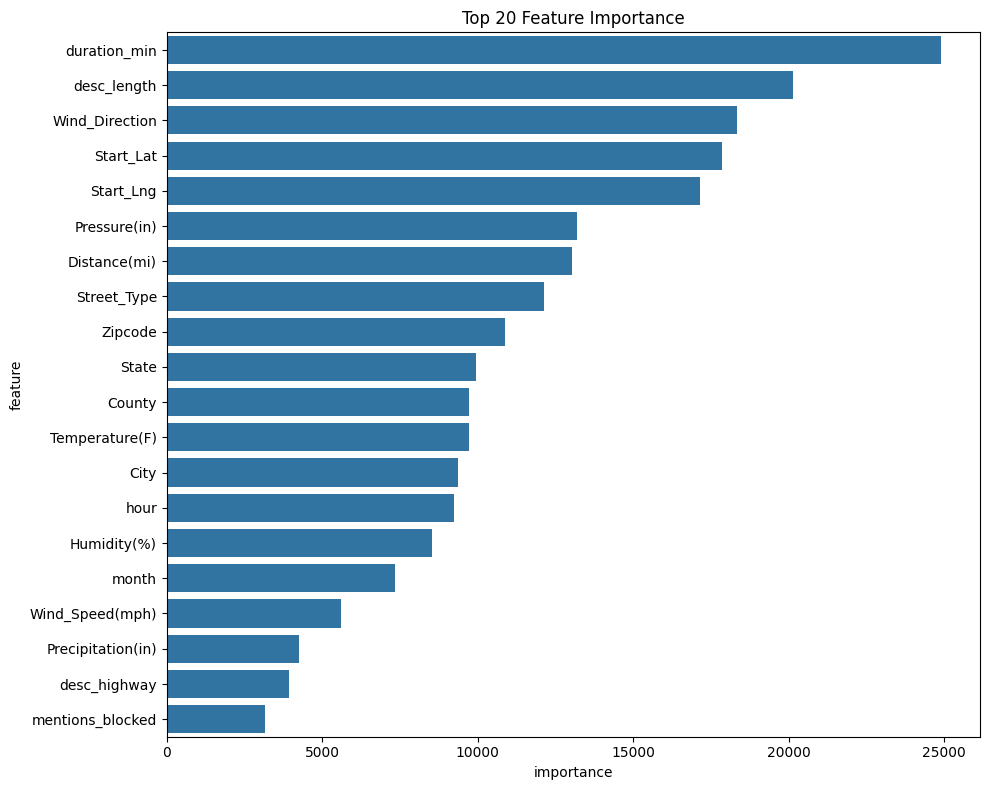

In [44]:
# Feature importance
print("\n" + "=" * 60)
print("TOP 50 FEATURE IMPORTANCE")
print("=" * 60)
feat_imp = pd.DataFrame({
    'feature': X_test.columns,
    'importance': model4.feature_importances_
}).sort_values('importance', ascending=False)

print(feat_imp.head(50).to_string(index=False))

plt.figure(figsize=(10, 8))
sns.barplot(data=feat_imp.head(20), x='importance', y='feature')
plt.title('Top 20 Feature Importance')
plt.tight_layout()
plt.show()